In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import pandas as pd
pd.options.mode.chained_assignment = None
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
from sklearn.model_selection import train_test_split

In [2]:
data = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data",
                   sep=",",
                  names=['I', 'II' ,'III', 'IV', 'V', 'VI', 'VII', 'VIII', 'IX', 'X', 'XI', 'XII', 'XIII', 'XIV'])

In [3]:
data = data.replace(to_replace='?', value=0.)

In [4]:
data['Label'] = 0
data['Label'][data.iloc[:,13]>0] = 1
data.drop(data.columns[13], axis=1)

data = data.drop('XIV', axis=1)

In [5]:
cols2zscore = data.columns[:13]
data[cols2zscore] = data[cols2zscore].astype(float)

for col in cols2zscore:
    meanval   = np.mean(data[col])
    stdev     = np.std(data[col],ddof=1)
    data[col] = (data[col]-meanval) / stdev

In [6]:
data.describe();

In [7]:
np_data = np.array(data.iloc[:,0:-1])
np_labels = np.array(data.iloc[:,13])

In [8]:
torch_data = torch.tensor(np_data).float()
torch_labels = torch.tensor(np_labels).float()
torch_labels.unsqueeze_(1);

In [9]:
x_train, x_test, y_train, y_test = train_test_split(torch_data,torch_labels, train_size=.9)

In [10]:
train_dataset = TensorDataset(x_train, y_train)
test_dataset = TensorDataset(x_test, y_test)

In [11]:
train_dataset.tensors[0].shape

torch.Size([272, 13])

In [12]:
train_loader = DataLoader(train_dataset, batch_size=12, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=x_test.shape[0], shuffle=True)

In [13]:
class HeartModel(nn.Module):
    def __init__(self):
        super(HeartModel, self).__init__()
        self.input = nn.Linear(13, 32)
        self.batch_norm1 = nn.BatchNorm1d(32)
        self.fc1 = nn.Linear(32, 32)
        self.batch_norm2 = nn.BatchNorm1d(32)
        self.fc2 = nn.Linear(32, 32)
        self.batch_norm3 = nn.BatchNorm1d(32)
        self.output = nn.Linear(32, 1)
        self.relu = nn.ReLU()
    def forward(self, x):
        out = self.input(x)
        out = self.relu(out)
        out = self.batch_norm1(out)
        
        out = self.fc1(out)
        out = self.relu(out)
        out = self.batch_norm2(out)
        
        out = self.fc2(out)
        out = self.relu(out)
        out = self.batch_norm3(out)
        
        out = self.output(out)
        return out

In [14]:
model = HeartModel()
optimizer = torch.optim.Adam(model.parameters(), lr=.01)
loss_fn = nn.BCEWithLogitsLoss()

In [15]:
weights_num = 0
for name, p in model.named_parameters():
    if 'weight' in name:
        weights_num += p.numel()

In [16]:
def compute_L(model, lmbd):
    L1 = 0
    for name, p in model.named_parameters():
        if 'weight' in name:
            L1 += torch.sum( torch.abs(p) )

    L2 = 0
    for name, p in model.named_parameters():
        if 'weight' in name:
            L2 += torch.sum( p**2 )
    
    return ( (L1/weights_num) + (L2/weights_num) )*lmbd   

In [17]:
# x,y = next(iter(test_loader))
# with torch.no_grad():
#     outputs = model(x)
#     print(outputs)
#     print()
#     print(F.sigmoid(outputs))
#     print()
#     print((F.sigmoid(outputs) > .5))
#     print()
#     print((F.sigmoid(outputs) > .5) == y)
#     print()
#     print(y)
#     acc = (((F.sigmoid(outputs) > .5) == y).float()*100).mean()

In [18]:
def train(epochs):
    loss_per_epoch = []
    test_loss_per_epoch = []
    acc_per_epoch = []
    test_acc_per_epoch = []
    for e in range(epochs):
        loss_per_batch = []
        acc_per_batch = []
        for x,y in train_loader:
            outputs = model(x)
            acc = (((F.sigmoid(outputs) > .5) == y).float()*100).mean()
            acc_per_batch.append(acc.item())
            
            loss = loss_fn(outputs, y)
            loss = loss + compute_L(model, .001)
            loss_per_batch.append(loss.item())
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
        x,y = next(iter(test_loader))
        with torch.no_grad():
            outputs = model(x)
            loss = loss_fn(outputs, y)
            loss = loss + compute_L(model, .001)
            test_loss_per_epoch.append(loss.item())
            acc = (((F.sigmoid(outputs) > .5) == y).float()*100).mean()
            test_acc_per_epoch.append(acc.item())
            
        loss_per_epoch.append(np.mean(loss_per_batch))
        acc_per_epoch.append(np.mean(acc_per_batch))
    return loss_per_epoch, acc_per_epoch, test_loss_per_epoch, test_acc_per_epoch

In [19]:
loss_per_epoch, acc_per_epoch, test_loss_per_epoch, test_acc_per_epoch = train(50)

C:\Users\molszo\Anaconda3\lib\site-packages\torch\nn\functional.py:1967: UserWarning: nn.functional.sigmoid is deprecated. Use torch.sigmoid instead.
  warnings.warn("nn.functional.sigmoid is deprecated. Use torch.sigmoid instead.")


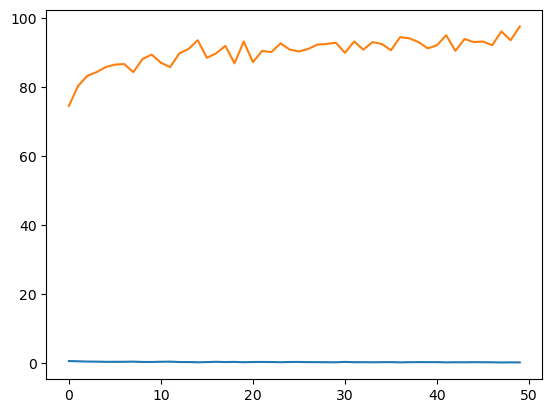

In [20]:
plt.plot(loss_per_epoch)
plt.plot(acc_per_epoch)

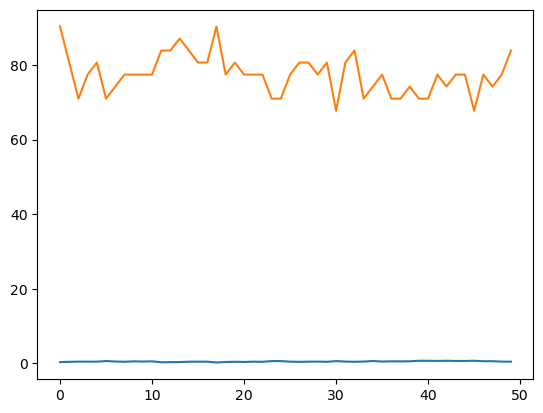

In [21]:
plt.plot(test_loss_per_epoch)
plt.plot(test_acc_per_epoch)